Liver Patient Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Dataset loading
df = pd.read_csv("liver_patient_dataset.csv")


In [3]:
df.head(10)

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,Liver Disease
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,Liver Disease
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,Liver Disease
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,Liver Disease
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,Liver Disease
5,46,Male,1.8,0.7,208,19,14,7.6,4.4,1.30,Liver Disease
6,26,Female,0.9,0.2,154,16,12,7.0,3.5,1.00,Liver Disease
7,29,Female,0.9,0.3,202,14,11,6.7,3.6,1.10,Liver Disease
8,17,Male,0.9,0.3,202,22,19,7.4,4.1,1.20,No Liver Disease
9,55,Male,0.7,0.2,290,53,58,6.8,3.4,1.00,Liver Disease


In [4]:
print("shape:", df.shape)

shape: (583, 11)


In [5]:
print("info")
df.info()

info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        583 non-null    int64  
 1   Gender     583 non-null    object 
 2   TB         583 non-null    float64
 3   DB         583 non-null    float64
 4   Alkphos    583 non-null    int64  
 5   Sgpt       583 non-null    int64  
 6   Sgot       583 non-null    int64  
 7   TP         583 non-null    float64
 8   ALB        583 non-null    float64
 9   A/G Ratio  583 non-null    float64
 10  Selector   583 non-null    object 
dtypes: float64(5), int64(4), object(2)
memory usage: 50.2+ KB


In [6]:
# The dataset numeric value

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,583.0,44.746141,16.189833,4.0,33.0,45.00,58.0,90.0
TB,583.0,3.298799,6.209522,0.4,0.8,1.00,2.6,75.0
DB,583.0,1.486106,2.808498,0.1,0.2,0.30,1.3,19.7
Alkphos,583.0,290.576329,242.937989,63.0,175.5,208.00,298.0,2110.0
Sgpt,583.0,80.713551,182.620356,10.0,23.0,35.00,60.5,2000.0
Sgot,583.0,109.910806,288.918529,10.0,25.0,42.00,87.0,4929.0
TP,583.0,6.483190,1.085451,2.7,5.8,6.60,7.2,9.6
ALB,583.0,3.141852,0.795519,0.9,2.6,3.10,3.8,5.5
A/G Ratio,583.0,0.946947,0.318495,0.3,0.7,0.93,1.1,2.8


In [7]:
numric_cols = ["AGE", "TB",	"DB", "Alkphos", "Sgpt", "Sgot", "TP", "ALB", "A/G Ratio" ]

In [8]:
categorical_cols = ["Gender", "Selector"]

In [9]:
print(numric_cols)

['AGE', 'TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot', 'TP', 'ALB', 'A/G Ratio']


In [10]:
print(categorical_cols)

['Gender', 'Selector']


In [21]:
# Cheak the missing value
df.isna().sum()

Age          0
Gender       0
TB           0
DB           0
Alkphos      0
Sgpt         0
Sgot         0
TP           0
ALB          0
A/G Ratio    0
Selector     0
dtype: int64

In [11]:
numric_cols = df.select_dtypes(include=["int64", "float64"]).columns
df[numric_cols].agg(["min", "max", "mean", "median"]).T

,min,max,mean,median
Age,4.0,90.0,44.746141,45.00
TB,0.4,75.0,3.298799,1.00
DB,0.1,19.7,1.486106,0.30
Alkphos,63.0,2110.0,290.576329,208.00
Sgpt,10.0,2000.0,80.713551,35.00
Sgot,10.0,4929.0,109.910806,42.00
TP,2.7,9.6,6.483190,6.60
ALB,0.9,5.5,3.141852,3.10
A/G Ratio,0.3,2.8,0.946947,0.93


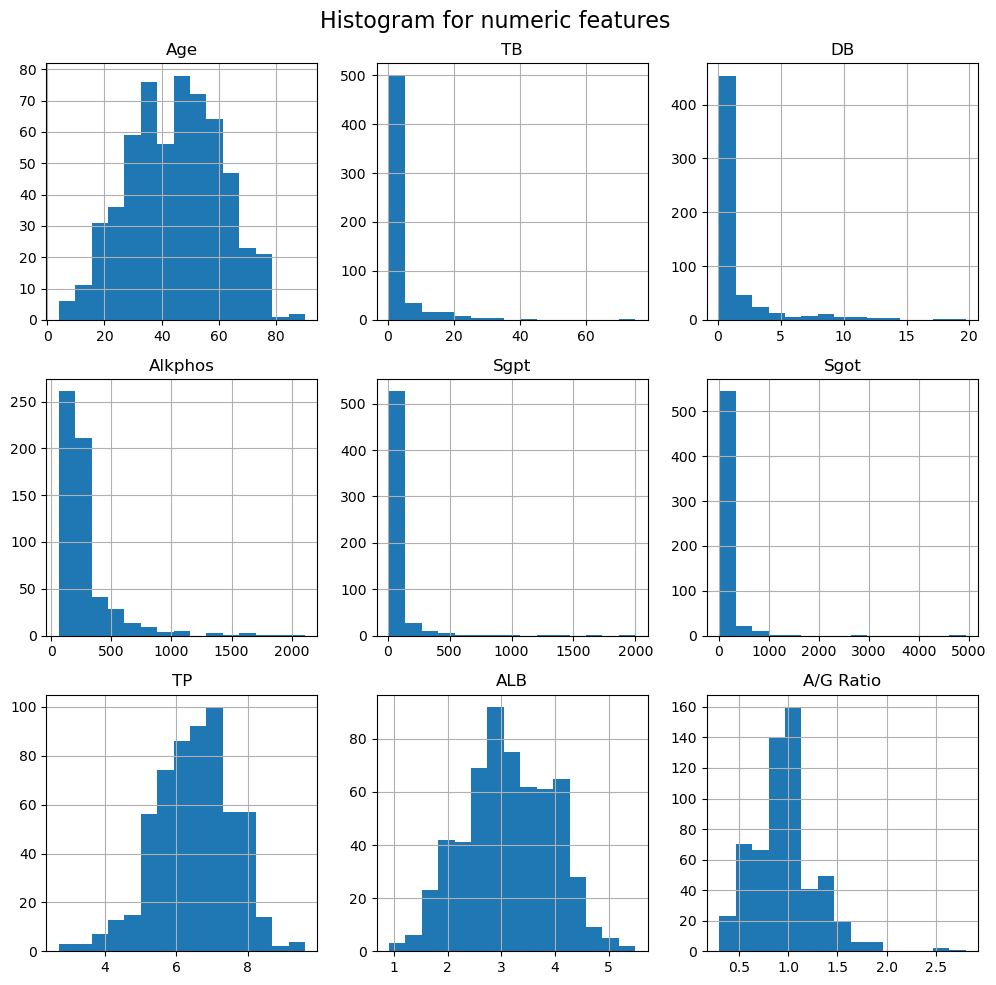

In [12]:
# Histogram for numeric features

df[numric_cols].hist(bins=15, figsize=(10, 10))

plt.suptitle("Histogram for numeric features", fontsize=16)
plt.tight_layout()
plt.show()

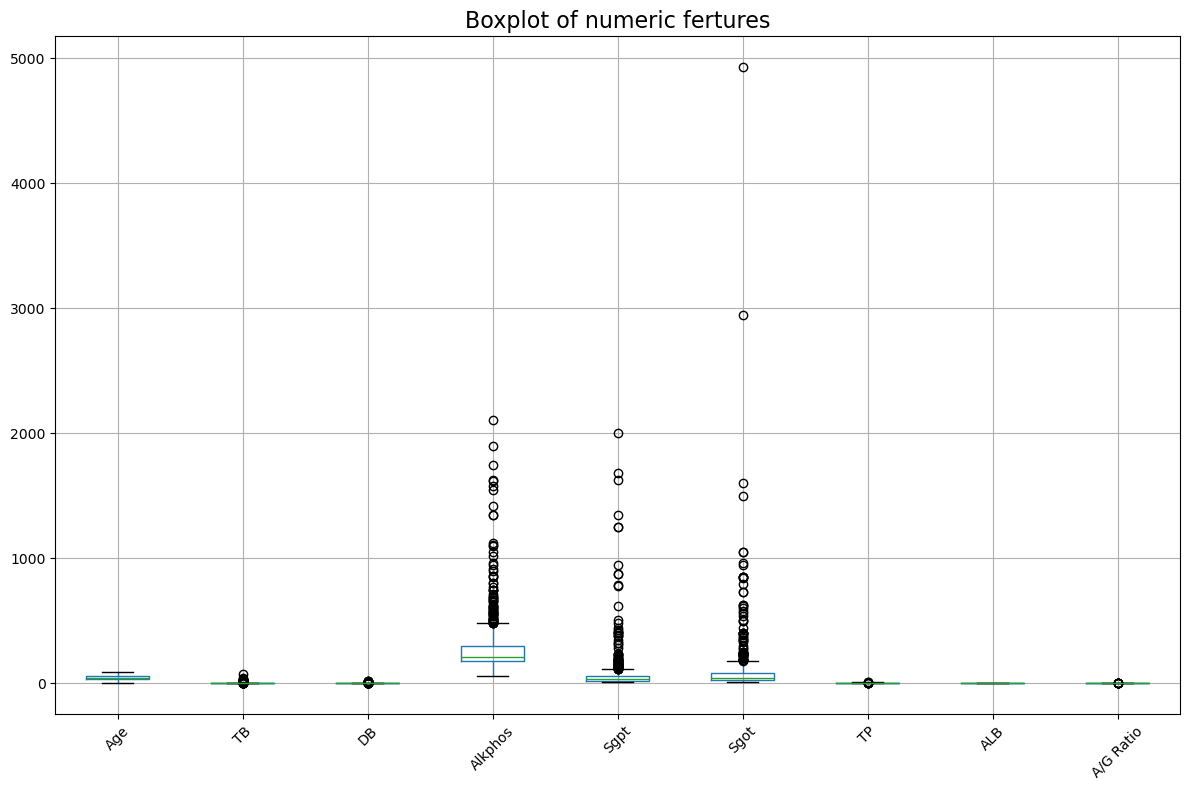

In [14]:
# Boxplt of numeric features

plt.figure(figsize=(12, 8))
df[numric_cols].boxplot()
plt.title("Boxplot of numeric fertures", fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

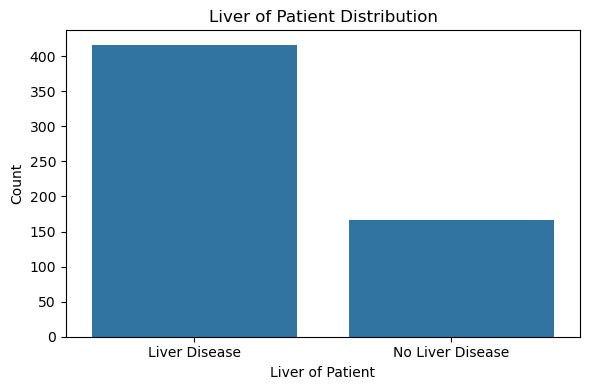

In [15]:
# Target distribution and class imbalance

plt.figure(figsize=(6, 4))
sns.countplot(x=df["Selector"])
plt.title("Liver of Patient Distribution")
plt.xlabel("Liver of Patient")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [16]:
df["Selector"].value_counts(normalize=True)

Selector
Liver Disease       0.713551
No Liver Disease    0.286449
Name: proportion, dtype: float64

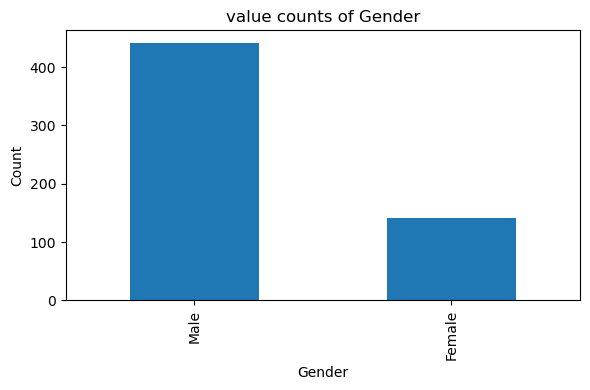

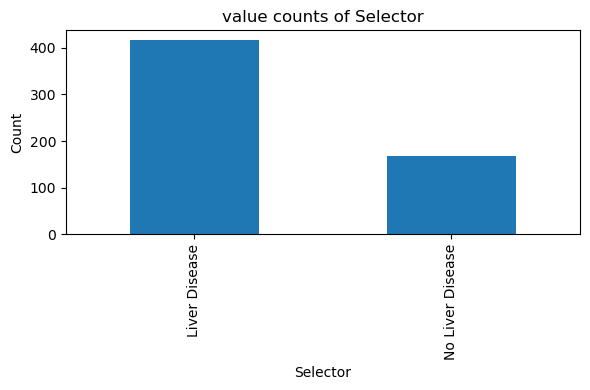

In [17]:
# Categorical features Explication

for c in categorical_cols:
    plt.figure(figsize=(6, 4))
    df[c].value_counts().plot(kind="bar")
    plt.title(f"value counts of {c}")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

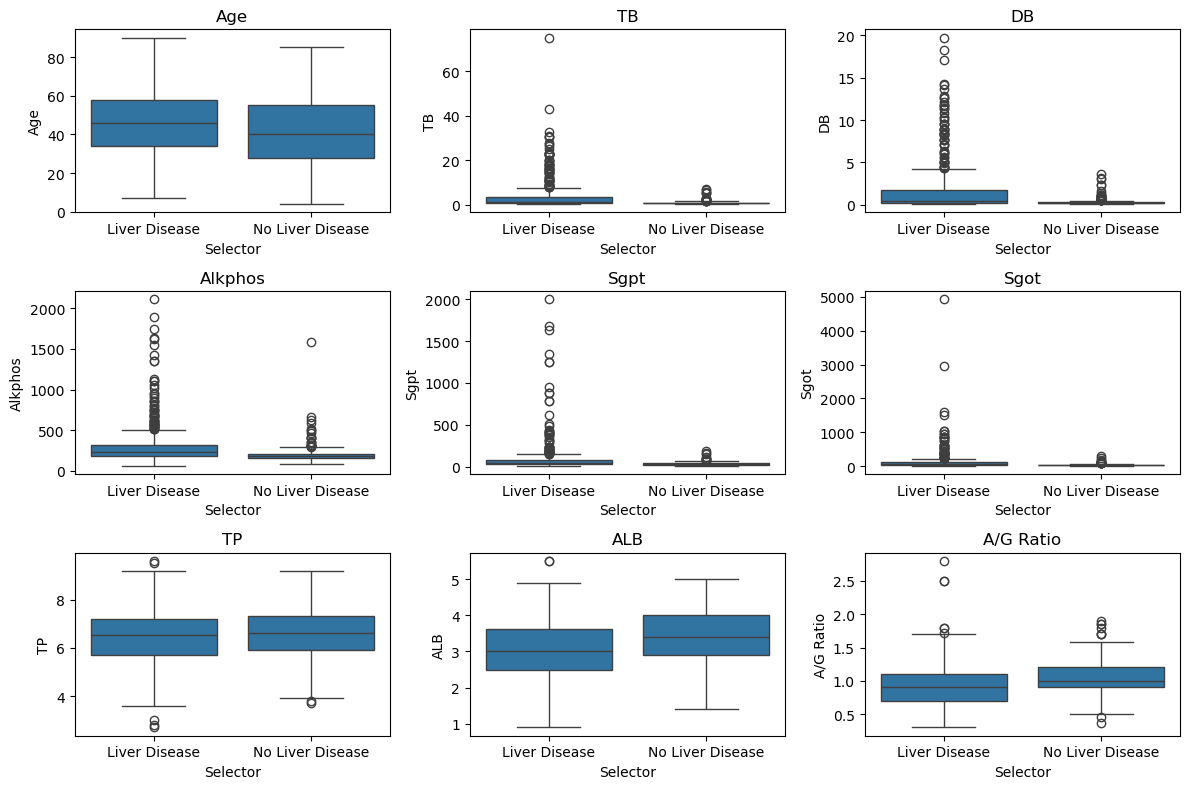

In [31]:
# Boxplot for numeric features split by Liver of Patient

plt.figure(figsize=(12, 8))

for i, col in enumerate(numric_cols):
    plt.subplot(3, 3, i+1)
    sns.boxplot(x=df["Selector"], y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()    

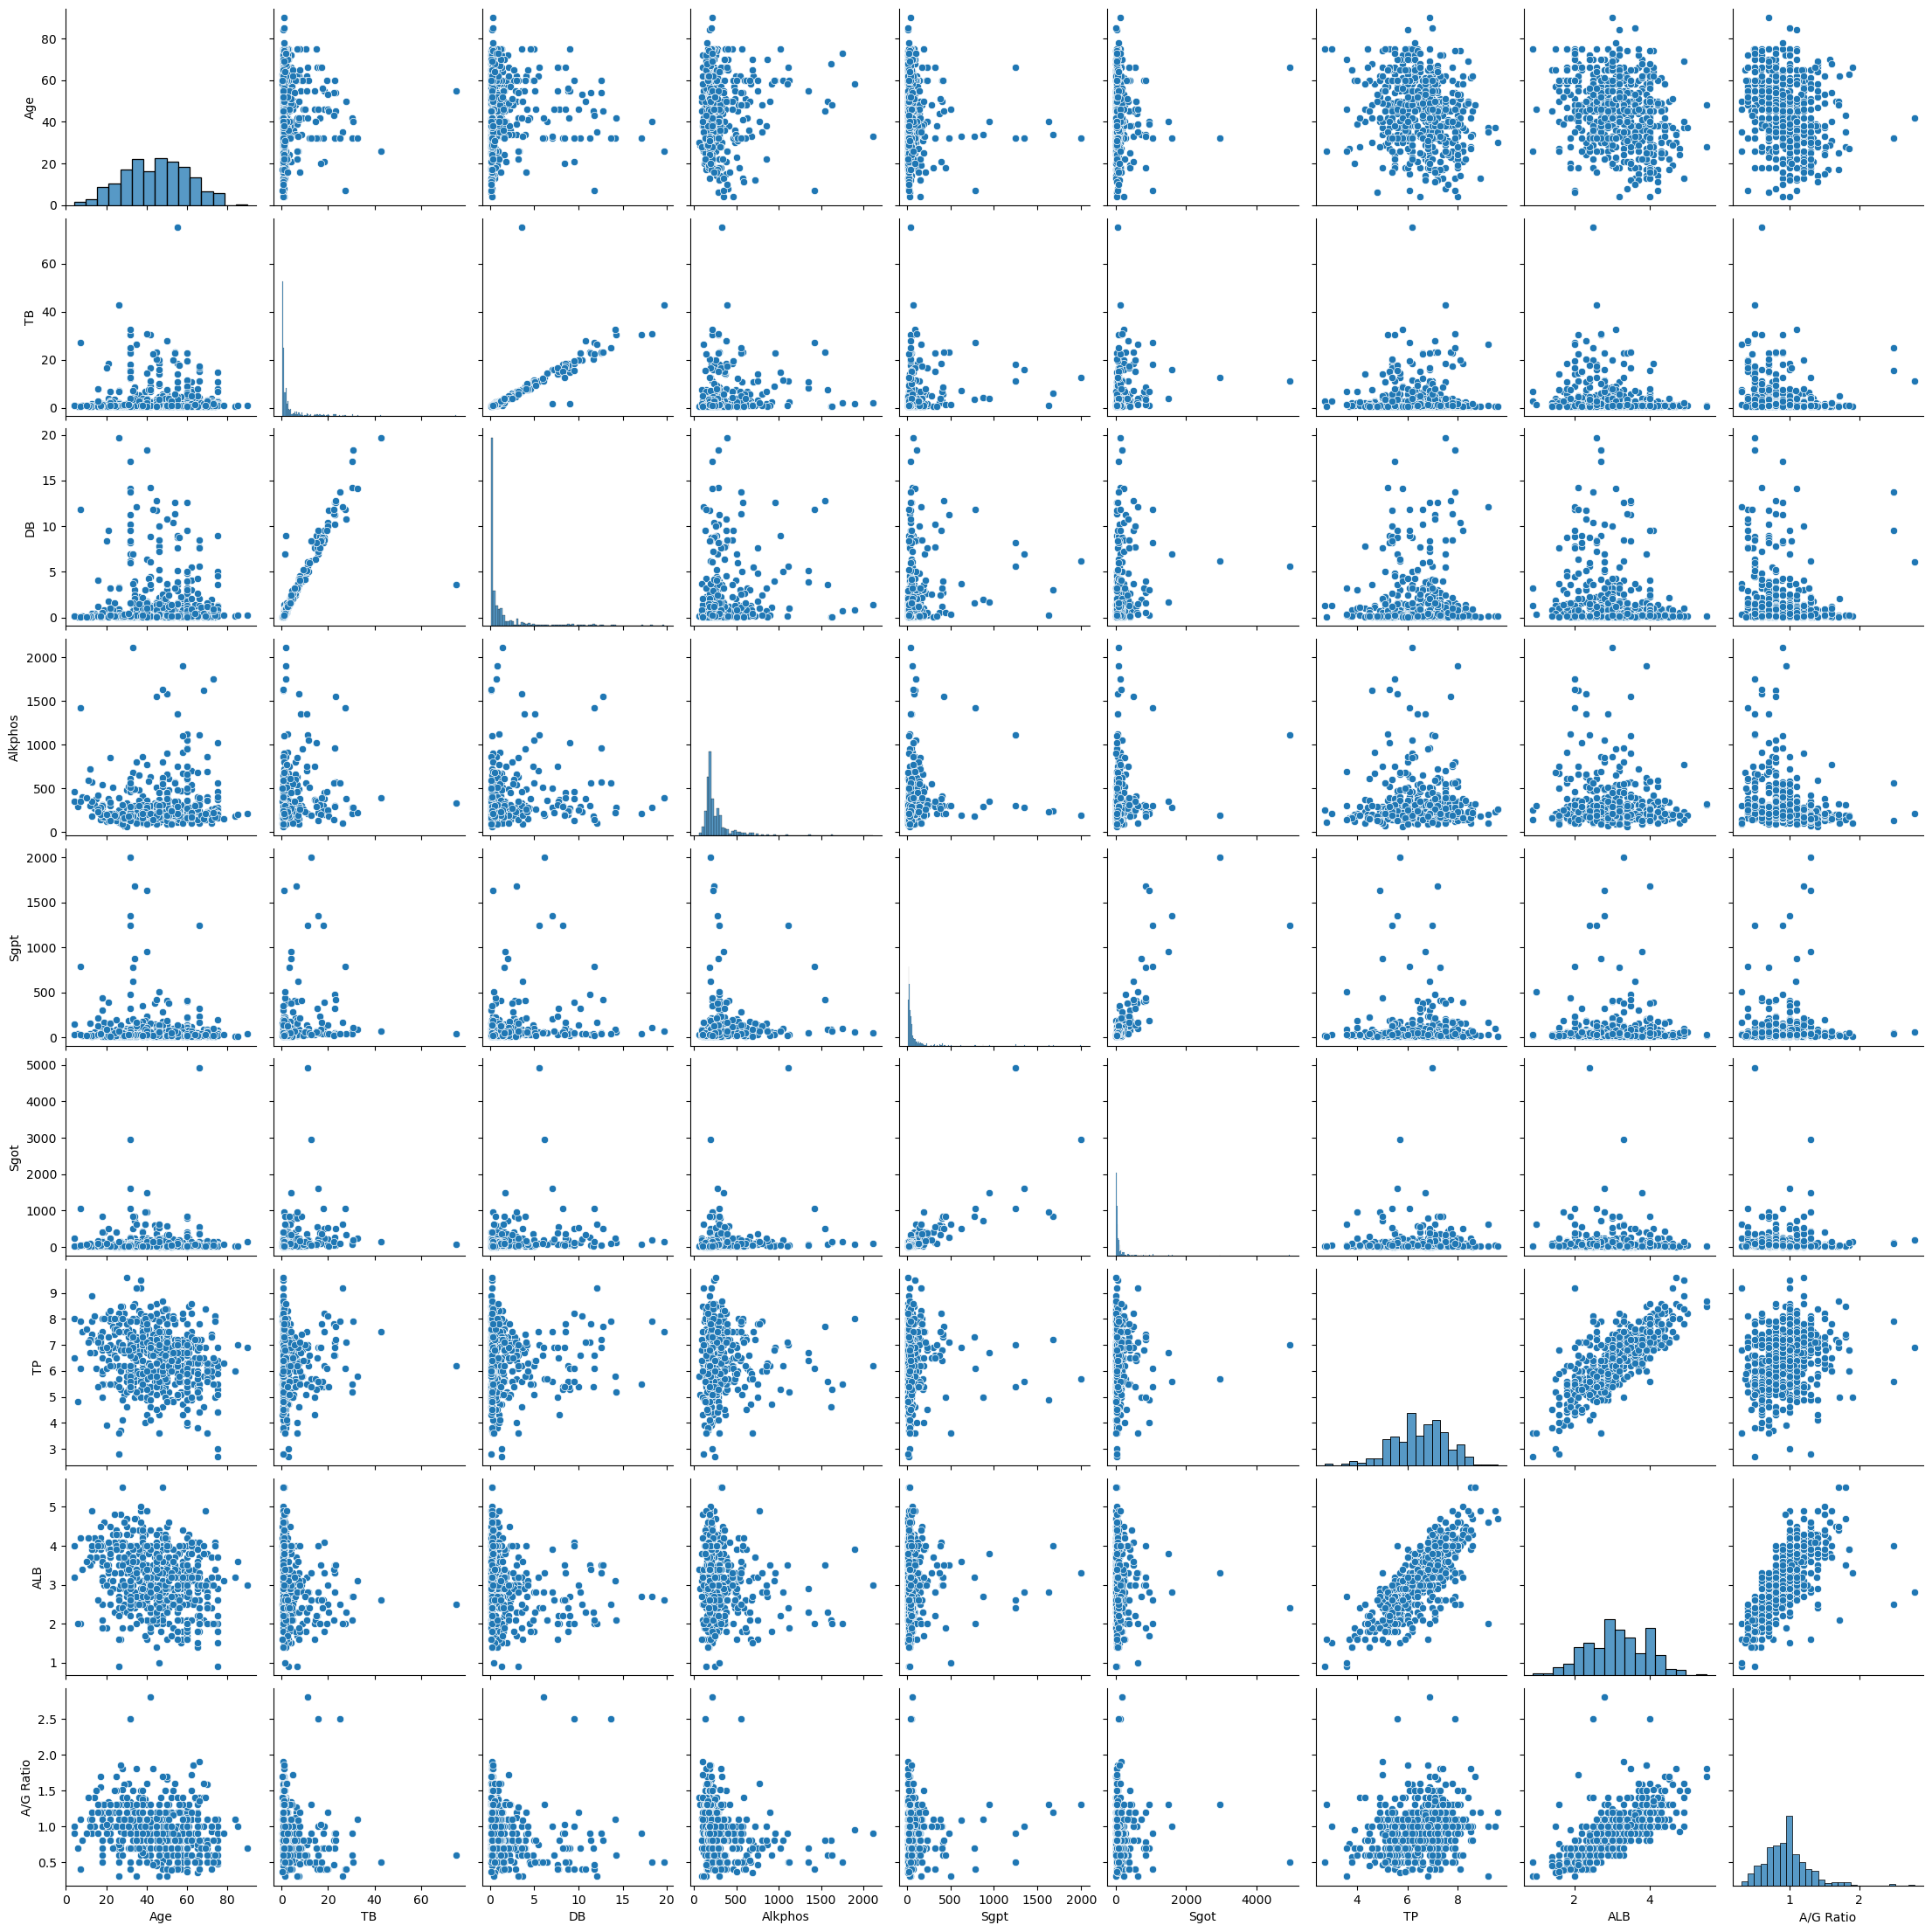

In [49]:
# Pair plot for a subplot Features

sns.pairplot(df[["Age", "TB", "DB", "Alkphos", "Sgpt", "Sgot", "TP", "ALB", "A/G Ratio"]])
hue="Selector"
plt.show()

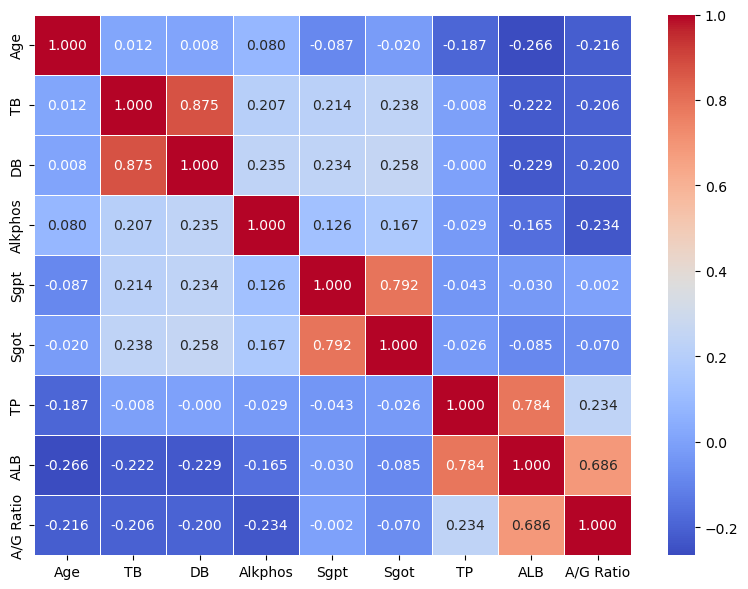

In [42]:
# Correlation matrix and heatmp

cor_matrix = df[numric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(cor_matrix, annot=True, cmap="coolwarm", fmt=".3f", linewidths='0.5')
plt.tight_layout()
plt.show()

Selector,Liver Disease,No Liver Disease
Gender,,
Female,0.647887,0.352113
Male,0.734694,0.265306


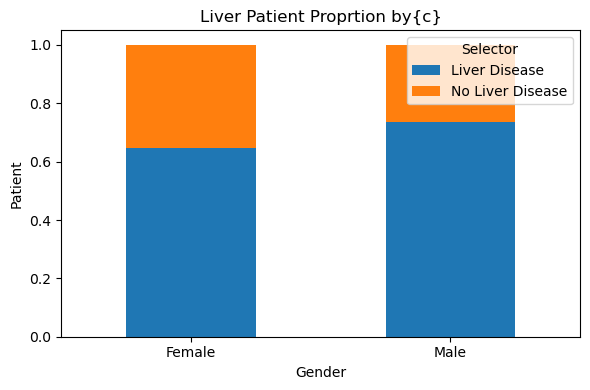

Selector,Liver Disease,No Liver Disease
Selector,,
Liver Disease,1.0,0.0
No Liver Disease,0.0,1.0


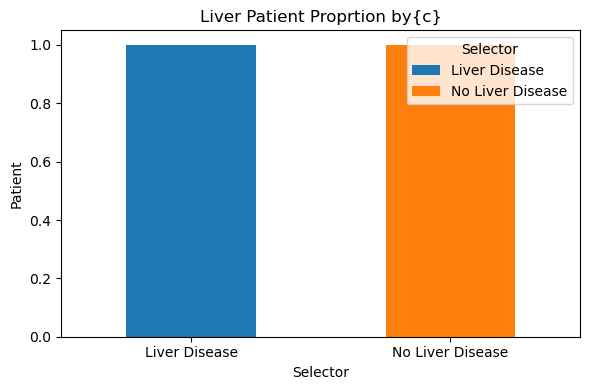

In [48]:
for c in categorical_cols:
    ct = pd.crosstab(df[c],df["Selector"], normalize="index")
    display(ct)

    ct.plot(kind="bar", stacked=True, figsize=(6, 4))
    plt.title("Liver Patient Proprtion by{c}")
    plt.ylabel("Patient")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()